
## Grouped vs Pooled Parameter Consistency: Linear and Offset–Power Seepage Models

This notebook compares grouped (per-event) parameter estimates to pooled (cross-event) best-by-holdout-RMSE models for seepage vs predictor relationships. We use a robust pipeline (Huber / soft-ℓ1) and no offset regularization. Global offset bounds enforce $x+\text{offset} \ge 0$ and a small, site-scale upper cap.

**Three models considered in this notebook**
1. Linear (Δh): $S = C_L\,\Delta h$
2. Offset–Power (Δh): $S = C_\Delta\,\Delta h\,z_{\Delta}^{\,b_{\Delta}}$
3. Offset–Power (visitor_h): $S = C_V\,\Delta h\,z_{V}^{\,b_{V}}$

### Model Formulation

We model seepage as:
$$
S \;=\; C(\cdot)\,\Delta h,
$$
where $C(\cdot)$ is an *effective berm conductance* that may vary with a driver.

### Non-dimensional drivers
Let
$$
m_{\Delta}=\mathrm{median}(\Delta h), \qquad m_{V}=\mathrm{median}(h_{\text{visitor}}).
$$
Define
$$
z_{\Delta}\equiv\frac{\Delta h+\text{offset}_{\Delta}}{m_{\Delta}}, \qquad
z_{V}\equiv\frac{h_{\text{visitor}}+\text{offset}_{V}}{m_{V}}.
$$
We use the generic name **offset** in each model (distinct parameters $\text{offset}_{\Delta}$ and $\text{offset}_{V}$); constraints $\Delta h+\text{offset}_{\Delta}\ge 0$ and $h_{\text{visitor}}+\text{offset}_{V}\ge 0$ ensure real-valued powers.

### Models
- **Constant $C_L$ (linear fit):**
$$
C(\cdot)= C_L \quad\Rightarrow\quad S= C_L\,\Delta h.
$$

- **Offset–power on $\Delta h$:**
$$
C(\cdot)= C_\Delta\,z_{\Delta}^{\,b_{\Delta}}
\quad\Rightarrow\quad
S \;=\; C_\Delta\,\Delta h\,z_{\Delta}^{\,b_{\Delta}}.
$$

- **Offset–power on visitor water level:**
$$
C(\cdot)= C_V\,z_{V}^{\,b_{V}}
\quad\Rightarrow\quad
S \;=\; C_V\,\Delta h\,z_{V}^{\,b_{V}}.
$$

Here the exponents $b_{\Delta}$ and $b_{V}$ are model-specific (estimated separately). The normalizations $m_{\Delta}$ and $m_{V}$ keep the powered terms unitless and stabilize estimation while preserving the physical units of $C$.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import least_squares, minimize_scalar

# -----------------------------
# Configuration
# -----------------------------
# Per-event training sample sizes to evaluate. For each value n, we'll train
# using the *last n* rows (by index order) for each event.
thresholds = [5]

# Fraction of each event's data reserved for a deterministic holdout set.
test_frac = 0.20

# Base seed used to make the event-wise shuffles deterministic and repeatable.
seed = 42

# Small epsilon to avoid division-by-zero and log-of-zero issues.
eps = 1e-12

# -----------------------------
# Model toggles / hyperparameters
# -----------------------------
# True  -> use plain SSE objectives (non-robust) everywhere.
# False -> use robust objectives (Soft-L1 for linear; Huber + IRLS for offset–power).
use_sse = True

# Huber threshold multiplier (~95% efficiency for Gaussian residuals).
huber_c = 1.345

# Optional L2 penalty on the offset during offset profiling; set to 0.0 to disable.
lam_off = 0.0

# Initial guess for offset (if a solver branch uses it).
off0 = 0.0

# -----------------------------
# Data location
# -----------------------------
# By default, load the pooled dataset from the local directory; fall back to
# ../data/processed if not present.
data_paths = [Path('pooled_event_df.csv'), Path('../data/processed/pooled_event_df.csv')]
data_path = next((p for p in data_paths if p.exists()), data_paths[-1])
print('Using data:', data_path)

Using data: ../data/processed/pooled_event_df.csv


In [2]:

# Load + clean
df = pd.read_csv(data_path)
df["delta_h"] = pd.to_numeric(df["delta_h"], errors="coerce")
df["seepage"] = pd.to_numeric(df["seepage"], errors="coerce")
if "visitor_h" not in df.columns:
    df["visitor_h"] = np.nan
else:
    df["visitor_h"] = pd.to_numeric(df["visitor_h"], errors="coerce")
df = df.dropna(subset=["seepage"]).copy()
df["n_full"] = df.groupby("event")["event"].transform("size").astype("int64")
df[["delta_h","visitor_h","seepage","event","n_full"]].head()

df.query('seepage > 4')
df = df.query('n_full > 5 and seepage < 4')

In [3]:
len(df.event.unique())

25

In [4]:

# Models & utils
def model_linear(K, x):
    return K * x

def model_power_offset_normref(K, off, b, x, x_ref):
    x_ref = max(float(x_ref), 1e-12)
    xp = np.maximum(x + off, 1e-12)
    return K * x * np.power(xp / x_ref, b)

def mad(arr):
    arr = np.asarray(arr, float)
    med = np.median(arr)
    return np.median(np.abs(arr - med))

def r2_centered(y, yhat):
    y = np.asarray(y, float); yhat = np.asarray(yhat, float)
    sst = np.sum((y - np.nanmean(y))**2); sse = np.sum((y - yhat)**2)
    return np.nan if sst <= 0 else 1.0 - sse / sst

def aic_gaussian(sse, n, k):
    s2 = max(float(sse) / max(n,1), 1e-30)
    return n*np.log(s2) + 2*k

def aic_c(sse, n, k):
    if n <= k + 1: return np.nan
    aic = aic_gaussian(sse, n, k)
    return aic + (2*k*(k+1)) / (n - k - 1)

def huber_rho_sum(resid, delta):
    r = np.asarray(resid, float); a = np.abs(r)
    rho = np.where(a <= delta, 0.5*r*r, delta*a - 0.5*delta*delta)
    return float(np.sum(rho))

def robust_wls_log_reg(Z, t, max_iter=30, tol=1e-8, huber_delta=None):
    Z = np.asarray(Z, float); t = np.asarray(t, float)
    X = np.column_stack([np.ones(len(Z)), Z])
    beta = np.linalg.lstsq(X, t, rcond=None)[0]
    for _ in range(max_iter):
        r = t - X @ beta
        s = 1.4826 * mad(r) + 1e-9
        delta = (huber_c * s) if huber_delta is None else huber_delta
        a = np.abs(r)
        w = np.where(a <= delta, 1.0, delta / (a + 1e-12))
        Xw = X * np.sqrt(w)[:, None]
        tw = t * np.sqrt(w)
        beta_new = np.linalg.lstsq(Xw, tw, rcond=None)[0]
        if np.max(np.abs(beta_new - beta)) < tol * (np.abs(beta).sum() + tol):
            beta = beta_new
            break
        beta = beta_new
    return beta

def solve_kb_for_offset_normref(off, x, y, x_ref, use_sse=False):
    x = np.asarray(x, float); y = np.asarray(y, float)
    x_safe = np.maximum(x, 1e-12)
    xp     = np.maximum(x + off, 1e-12)
    Z = np.log(xp) - np.log(max(x_ref, 1e-12))
    t = np.log(np.maximum(y, 1e-12)) - np.log(x_safe)
    if use_sse:
        X = np.column_stack([np.ones(len(Z)), Z])
        alpha, b = np.linalg.lstsq(X, t, rcond=None)[0]
    else:
        alpha, b = robust_wls_log_reg(Z, t)
    K = float(np.exp(alpha))
    yhat = model_power_offset_normref(K, off, b, x, x_ref)
    return K, float(b), yhat

def global_offset_bounds(x_series):
    x = x_series.to_numpy(float)
    offset_lb = -float(np.nanmin(x)) + 1e-9
    q05, q95 = np.nanquantile(x, [0.05, 0.95])
    R = float(q95 - q05)
    site_cap = 1
    offset_ub = min(0.30*R, site_cap)
    if offset_ub <= offset_lb + 1e-6:
        offset_ub = offset_lb + max(0.05*R, 0.05)
    return offset_lb, offset_ub


In [5]:

# Pooled evaluation by thresholds
def make_fixed_cohort_and_holdout(df_in, thresholds, x_col):
    NSTAR = max(thresholds)
    dfx = df_in.dropna(subset=[x_col, "seepage"]).copy()
    dfx["n"] = dfx.groupby("event")["event"].transform("size").astype("int64")
    cohort = dfx.loc[ dfx["n"] >= NSTAR ].copy()
    if cohort.empty:
        NSTAR = int(dfx["n"].max())
        cohort = dfx.loc[ dfx["n"] >= NSTAR ].copy()
    parts_pool, parts_hold = [], []
    for e, g in cohort.groupby("event"):
        seed_for_event = seed + (abs(hash(str(e))) % 10**6)
        g = g.sample(frac=1.0, random_state=seed_for_event).reset_index(drop=True)
        n_e = len(g); n_test = max(1, int(np.ceil(test_frac * n_e)))
        parts_hold.append(g.iloc[:n_test].assign(split="test"))
        parts_pool.append(g.iloc[n_test:].assign(split="pool"))
    holdout = pd.concat(parts_hold, ignore_index=True)
    train_pool = pd.concat(parts_pool, ignore_index=True)
    return train_pool, holdout

def eval_by_thresholds(train_pool, holdout, thresholds, x_col, use_sse=False):
    x_ref = float(train_pool[x_col].median())
    lb, ub = global_offset_bounds(pd.concat([train_pool[x_col], holdout[x_col]], axis=0))
    rows = []
    for n in thresholds:
        subs = [g.head(min(n, len(g))) for _, g in train_pool.groupby("event")]
        train = pd.concat(subs, ignore_index=True)
        x_tr, y_tr = train[x_col].to_numpy(float), train["seepage"].to_numpy(float)
        x_te, y_te = holdout[x_col].to_numpy(float), holdout["seepage"].to_numpy(float)
        n_tr = len(x_tr)

        # Linear (through origin)
        K0 = float(np.dot(x_tr, y_tr) / max(np.dot(x_tr, x_tr), eps))
        def resid_lin(p): return y_tr - model_linear(p[0], x_tr)
        if use_sse:
            res_lin = least_squares(lambda p: resid_lin(p), x0=[max(K0, 1e-12)],
                                    bounds=([1e-12],[np.inf]), loss="linear")
        else:
            r0 = resid_lin([K0]); scale_y = 1.4826 * mad(r0) + 1e-9
            res_lin = least_squares(lambda p: resid_lin(p), x0=[max(K0, 1e-12)],
                                    bounds=([1e-12],[np.inf]), loss="soft_l1", f_scale=scale_y)
        K_lin = float(res_lin.x[0])
        yhat_tr_lin = model_linear(K_lin, x_tr)
        sse_tr_lin  = float(np.sum((y_tr - yhat_tr_lin)**2))
        aicc_lin    = aic_c(sse_tr_lin, n_tr, k=1)
        yhat_te_lin = model_linear(K_lin, x_te)
        rmse_lin    = float(np.sqrt(np.mean((y_te - yhat_te_lin)**2)))
        r2_te_lin   = r2_centered(y_te, yhat_te_lin)

        # Offset–power
        def profile_obj(off):
            _, _, yhat = solve_kb_for_offset_normref(off, x_tr, y_tr, x_ref, use_sse=use_sse)
            if use_sse:
                return float(np.sum((y_tr - yhat)**2))
            else:
                delta = huber_c * (1.4826 * mad(y_tr - yhat) + 1e-9)
                return huber_rho_sum(y_tr - yhat, delta=delta) + lam_off * (off - off0)**2

        lo, hi = lb + 1e-9, ub - 1e-9
        grid = np.linspace(lo, hi, 41)
        
        off_init = float(grid[int(np.argmin([profile_obj(o) for o in grid]))])
        left, right = max(lo, off_init - 0.25*(hi-lo)), min(hi, off_init + 0.25*(hi-lo))
        res_off = minimize_scalar(profile_obj, bounds=(left, right), method="bounded", options={"xatol": 1e-6})
        offp = float(res_off.x)

        K_pow, b_pow, yhat_tr_pow = solve_kb_for_offset_normref(offp, x_tr, y_tr, x_ref, use_sse=use_sse)
        sse_tr_pow = float(np.sum((y_tr - yhat_tr_pow)**2))
        aicc_pow   = aic_c(sse_tr_pow, n_tr, k=3)
        yhat_te_pow = model_power_offset_normref(K_pow, offp, b_pow, x_te, x_ref)
        rmse_pow    = float(np.sqrt(np.mean((y_te - yhat_te_pow)**2)))
        r2_te_pow   = r2_centered(y_te, yhat_te_pow)

        rows.append({
            "n": n, "n_train": n_tr, "x_col": x_col, "x_ref": x_ref,
            "AICc_lin": aicc_lin, "AICc_pow": aicc_pow,
            "RMSE_lin": rmse_lin, "RMSE_pow": rmse_pow, "dRMSE": rmse_pow - rmse_lin,
            "R2_te_lin": r2_te_lin, "R2_te_pow": r2_te_pow, "K_lin": K_lin,
            "K_pow": K_pow, "offset": offp, "b": b_pow,
        })
    out = pd.DataFrame(rows)
    num_cols = out.select_dtypes(include=[np.number]).columns
    out[num_cols] = out[num_cols].round(3)
    out[num_cols] = out[num_cols].mask(np.isclose(out[num_cols], 0, atol=5e-4), 0.0)
    return out


In [6]:
!open .

In [7]:

# Run pooled evaluations
train_pool_dh, holdout_dh = make_fixed_cohort_and_holdout(df, thresholds, "delta_h")
eval_dh = eval_by_thresholds(train_pool_dh, holdout_dh, thresholds, "delta_h", use_sse=use_sse)

has_vis = df["visitor_h"].notna().any()
if has_vis:
    df_vis = df.dropna(subset=["visitor_h"]).copy()
    train_pool_vis, holdout_vis = make_fixed_cohort_and_holdout(df_vis, thresholds, "visitor_h")
    eval_vis = eval_by_thresholds(train_pool_vis, holdout_vis, thresholds, "visitor_h", use_sse=use_sse)
else:
    eval_vis = pd.DataFrame()

def best_row_by_rmse(df_eval):
    i_lin = df_eval["RMSE_lin"].astype(float).idxmin()
    i_pow = df_eval["RMSE_pow"].astype(float).idxmin()
    return df_eval.loc[i_lin], df_eval.loc[i_pow]

best_lin_dh, best_pow_dh = best_row_by_rmse(eval_dh)

rows = [{
    "model": "Linear (Δh)",
    "n_best": int(best_lin_dh["n"]),
    "RMSE_test": float(best_lin_dh["RMSE_lin"]),
    "R2_test": float(best_lin_dh["R2_te_lin"]),
    "AICc_train": float(best_lin_dh["AICc_lin"]),
    "C": float(best_lin_dh["K_lin"]), "offset": np.nan, "b": np.nan,
},{
    "model": "Offset–power (Δh)",
    "n_best": int(best_pow_dh["n"]),
    "RMSE_test": float(best_pow_dh["RMSE_pow"]),
    "R2_test": float(best_pow_dh["R2_te_pow"]),
    "AICc_train": float(best_pow_dh["AICc_pow"]),
    "C": float(best_pow_dh["K_pow"]), "offset": float(best_pow_dh["offset"]), "b": float(best_pow_dh["b"]),
}]

if has_vis and not eval_vis.empty:
    _, best_pow_vis = best_row_by_rmse(eval_vis)
    rows += [{
        "model": "Offset–power (visitor_h)",
        "n_best": int(best_pow_vis["n"]),
        "RMSE_test": float(best_pow_vis["RMSE_pow"]),
        "R2_test": float(best_pow_vis["R2_te_pow"]),
        "AICc_train": float(best_pow_vis["AICc_pow"]),
        "C": float(best_pow_vis["K_pow"]), "offset": float(best_pow_vis["offset"]), "b": float(best_pow_vis["b"]),
    }]

pooled_best = pd.DataFrame(rows)
pooled_best


,model,n_best,RMSE_test,R2_test,AICc_train,C,offset,b
0,Linear (Δh),5,0.588,0.459,-124.991,1.093,NaN,NaN
1,Offset–power (Δh),5,0.561,0.507,-120.478,1.125,-0.685,0.171
2,Offset–power (visitor_h),5,0.555,0.518,-123.016,0.935,-1.709,0.350


In [8]:

# Grouped per-event fits
def per_event_fits(df_in, x_col, min_n=6, use_sse=False):
    dfx = df_in.dropna(subset=[x_col, "seepage"]).copy()
    rows = []
    for e, g in dfx.groupby("event"):
        x = g[x_col].to_numpy(float); y = g["seepage"].to_numpy(float)
        n = len(x)
        if n < min_n: continue
        x_ref_evt = float(np.median(x))
        lb, ub = global_offset_bounds(g[x_col])

        K0 = float(np.dot(x, y) / max(np.dot(x, x), 1e-12))
        def resid_lin_evt(p): return y - model_linear(p[0], x)
        if use_sse:
            rl = least_squares(lambda p: resid_lin_evt(p), x0=[max(K0, 1e-12)],
                               bounds=([1e-12],[np.inf]), loss="linear")
        else:
            r0 = resid_lin_evt([K0]); scale_y = 1.4826 * mad(r0) + 1e-9
            rl = least_squares(lambda p: resid_lin_evt(p), x0=[max(K0, 1e-12)],
                               bounds=([1e-12],[np.inf]), loss="soft_l1", f_scale=scale_y)
        Kl = float(rl.x[0]); yhat_l = model_linear(Kl, x); r2l = r2_centered(y, yhat_l)

        def obj_evt(off):
            _, _, yhat = solve_kb_for_offset_normref(off, x, y, x_ref_evt, use_sse=use_sse)
            if use_sse:
                return float(np.sum((y - yhat)**2))
            else:
                delta = huber_c * (1.4826 * mad(y - yhat) + 1e-9)
                return huber_rho_sum(y - yhat, delta=delta) + lam_off * (off - off0)**2

        lo, hi = lb + 1e-9, ub - 1e-9
        grid = np.linspace(lo, hi, 41)
        off_init = float(grid[int(np.argmin([obj_evt(o) for o in grid]))])
        left, right = max(lo, off_init - 0.25*(hi-lo)), min(hi, off_init + 0.25*(hi-lo))
        rp = minimize_scalar(obj_evt, bounds=(left, right), method="bounded", options={"xatol": 1e-6})
        offp = float(rp.x)

        Kp, bp, yhat_p = solve_kb_for_offset_normref(offp, x, y, x_ref_evt, use_sse=use_sse)
        r2p = r2_centered(y, yhat_p)

        rows.append({
            "event": e, "n": n, "x_col": x_col, "x_ref_evt": x_ref_evt,
            "K_lin": Kl, "R2_lin": r2l,
            "K_pow": Kp, "offset": offp, "b": bp, "R2_pow": r2p
        })
    out = pd.DataFrame(rows).sort_values("event").reset_index(drop=True)
    num_cols = out.select_dtypes(include=[np.number]).columns
    out[num_cols] = out[num_cols].round(3)
    out[num_cols] = out[num_cols].mask(np.isclose(out[num_cols], 0, atol=5e-4), 0.0)
    return out

ev_dh = per_event_fits(df, "delta_h", min_n=6, use_sse=use_sse)
ev_vs = per_event_fits(df, "visitor_h", min_n=5, use_sse=use_sse) if df["visitor_h"].notna().any() else pd.DataFrame()



In [9]:

# Augmented table: pooled vs grouped stats + consistency deltas
def pct_diff(pooled, grouped_median):
    eps = 1e-12
    if pd.isna(pooled) or pd.isna(grouped_median):
        return np.nan
    denom = grouped_median if abs(grouped_median) > eps else (eps * np.sign(grouped_median if grouped_median != 0 else 1))
    return 100.0 * (pooled - grouped_median) / denom

def grouped_stats(ev_df, model_type):
    if ev_df.empty:
        return {}
    if model_type == "lin":
        d = {
            "Grouped C (median)": ev_df["K_lin"].median(),
            "Grouped C (mean)": ev_df["K_lin"].mean(),
            "Grouped R2 (median)": ev_df["R2_lin"].median(),
            "Grouped R2 (mean)": ev_df["R2_lin"].mean(),
        }
    else:
        d = {
            "Grouped C (median)": ev_df["K_pow"].median(),
            "Grouped C (mean)": ev_df["K_pow"].mean(),
            "Grouped offset (median)": ev_df["offset"].median(),
            "Grouped offset (mean)": ev_df["offset"].mean(),
            "Grouped b (median)": ev_df["b"].median(),
            "Grouped b (mean)": ev_df["b"].mean(),
            "Grouped R2 (median)": ev_df["R2_pow"].median(),
            "Grouped R2 (mean)": ev_df["R2_pow"].mean(),
        }
    return d

rows_aug = []
for _, r in pooled_best.iterrows():
    model = r["model"]
    is_pow = "Offset–power" in model
    ev = ev_dh if "Δh" in model else ev_vs
    pooled = {
        "Context": "Pooled (best by RMSE)",
        "Best model (predictor)": model,
        "n*": int(r["n_best"]),
        "Holdout RMSE": float(r["RMSE_test"]),
        "R² (test)": float(r["R2_test"]),
        "AICc (train)": float(r["AICc_train"]),
        "C (pooled)": float(r["C"]),
        "offset (pooled)": float(r["offset"]) if is_pow else np.nan,
        "b (pooled)": float(r["b"]) if is_pow else np.nan,
    }
    gstats = grouped_stats(ev, model_type=("pow" if is_pow else "lin"))

    pooled["Δ C vs grouped median (%)"] = pct_diff(pooled["C (pooled)"], gstats.get("Grouped C (median)", np.nan))
    if is_pow:
        pooled["Δ offset vs grouped median (%)"] = pct_diff(pooled["offset (pooled)"], gstats.get("Grouped offset (median)", np.nan))
        pooled["Δ b vs grouped median (%)"]      = pct_diff(pooled["b (pooled)"],      gstats.get("Grouped b (median)", np.nan))
    else:
        pooled["Δ offset vs grouped median (%)"] = np.nan
        pooled["Δ b vs grouped median (%)"]      = np.nan

    row = {**pooled, **{k: (float(v) if pd.notna(v) else np.nan) for k, v in gstats.items()}}
    rows_aug.append(row)

aug = pd.DataFrame(rows_aug)

# Clean & order
num_cols = aug.select_dtypes(include=[np.number]).columns
aug[num_cols] = aug[num_cols].round(3)
aug[num_cols] = aug[num_cols].mask(np.isclose(aug[num_cols], 0, atol=5e-4), 0.0)

ordered_cols = [
    "Context", "Best model (predictor)", "n*",
    "Holdout RMSE", "R² (test)", "AICc (train)",
    "C (pooled)", "Grouped C (median)", "Grouped C (mean)", "Δ C vs grouped median (%)",
    "offset (pooled)", "Grouped offset (median)", "Grouped offset (mean)", "Δ offset vs grouped median (%)",
    "b (pooled)", "Grouped b (median)", "Grouped b (mean)", "Δ b vs grouped median (%)",
    "Grouped R2 (median)", "Grouped R2 (mean)"
]
ordered_cols = [c for c in ordered_cols if c in aug.columns]
aug = aug[ordered_cols]
display(aug.T)


,0,1,2
Context,Pooled (best by RMSE),Pooled (best by RMSE),Pooled (best by RMSE)
Best model (predictor),Linear (Δh),Offset–power (Δh),Offset–power (visitor_h)
n*,5,5,5
Holdout RMSE,0.588,0.561,0.555
R² (test),0.459,0.507,0.518
AICc (train),-124.991,-120.478,-123.016
C (pooled),1.093,1.125,0.935
Grouped C (median),1.034,0.991,0.655
Grouped C (mean),1.061,1.07,0.74
Δ C vs grouped median (%),5.757,13.522,42.748


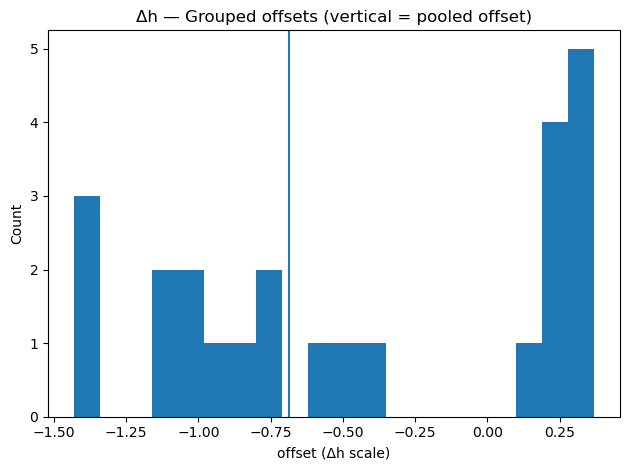

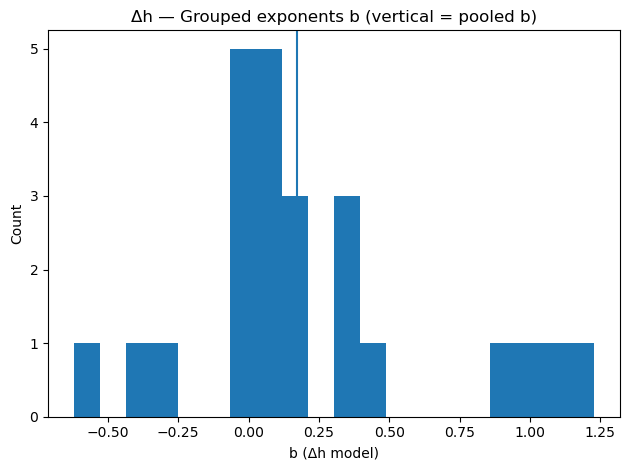

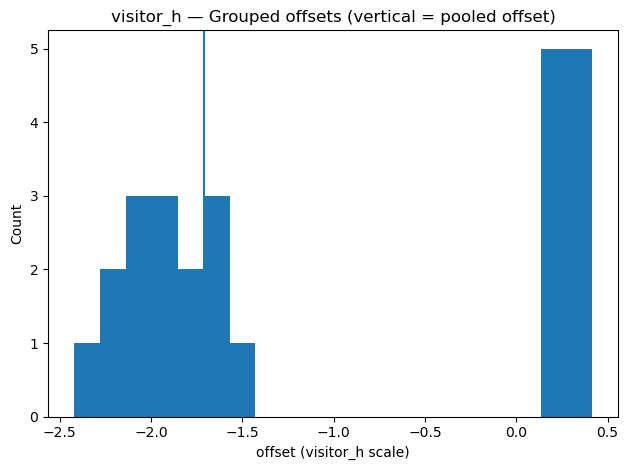

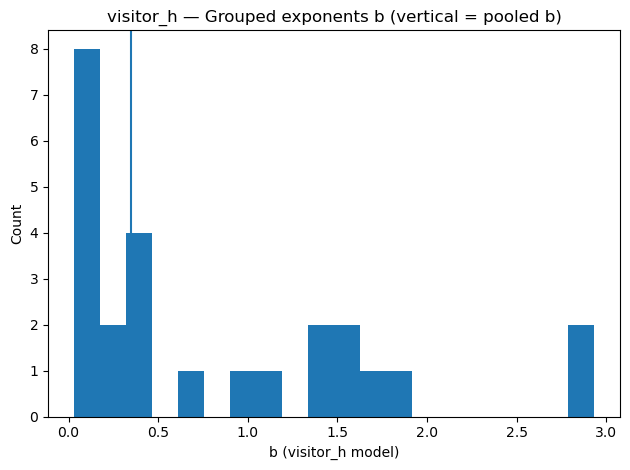

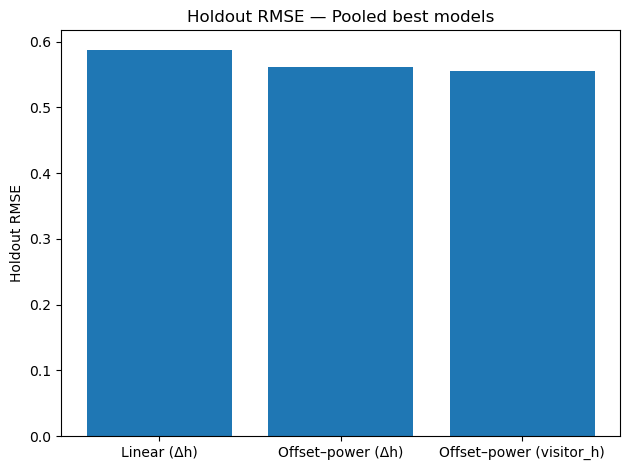

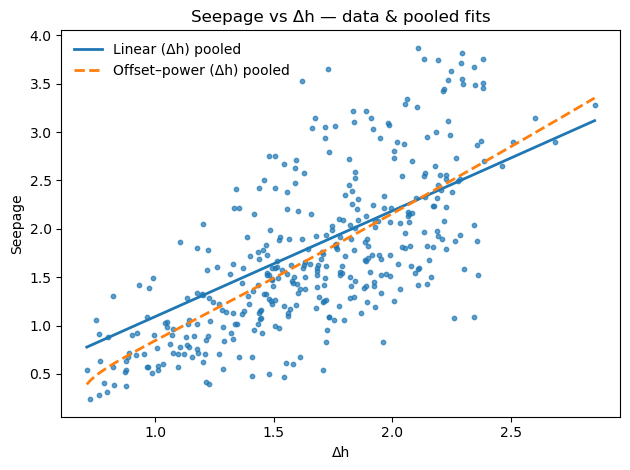

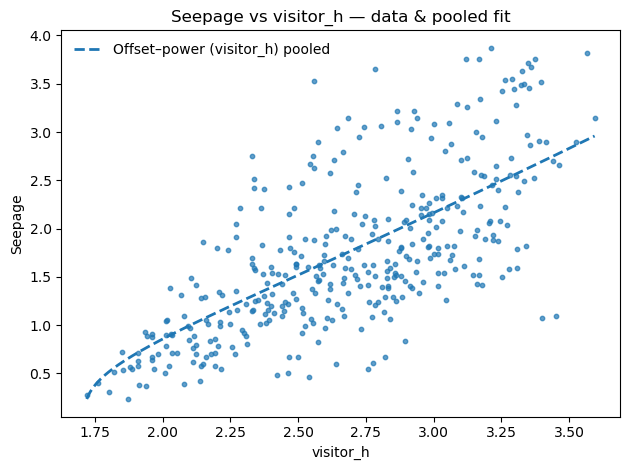

In [10]:
# Visuals

# Histograms of offset and b for Δh
if not ev_dh.empty:
    pooled_off_dh = aug.loc[aug["Best model (predictor)"]=="Offset–power (Δh)","offset (pooled)"].values
    pooled_b_dh   = aug.loc[aug["Best model (predictor)"]=="Offset–power (Δh)","b (pooled)"].values
    pooled_off_dh = pooled_off_dh[0] if len(pooled_off_dh)>0 else np.nan
    pooled_b_dh   = pooled_b_dh[0] if len(pooled_b_dh)>0 else np.nan

    plt.figure()
    plt.hist(ev_dh["offset"].dropna().values, bins=20)
    if np.isfinite(pooled_off_dh): plt.axvline(pooled_off_dh)
    plt.title("Δh — Grouped offsets (vertical = pooled offset)")
    plt.xlabel("offset (Δh scale)"); plt.ylabel("Count")
    plt.tight_layout(); plt.show()

    plt.figure()
    plt.hist(ev_dh["b"].dropna().values, bins=20)
    if np.isfinite(pooled_b_dh): plt.axvline(pooled_b_dh)
    plt.title("Δh — Grouped exponents b (vertical = pooled b)")
    plt.xlabel("b (Δh model)"); plt.ylabel("Count")
    plt.tight_layout(); plt.show()

# Histograms of offset and b for visitor_h
if not ev_vs.empty:
    pooled_off_vs = aug.loc[aug["Best model (predictor)"]=="Offset–power (visitor_h)","offset (pooled)"].values
    pooled_b_vs   = aug.loc[aug["Best model (predictor)"]=="Offset–power (visitor_h)","b (pooled)"].values
    pooled_off_vs = pooled_off_vs[0] if len(pooled_off_vs)>0 else np.nan
    pooled_b_vs   = pooled_b_vs[0] if len(pooled_b_vs)>0 else np.nan

    plt.figure()
    plt.hist(ev_vs["offset"].dropna().values, bins=20)
    if np.isfinite(pooled_off_vs): plt.axvline(pooled_off_vs)
    plt.title("visitor_h — Grouped offsets (vertical = pooled offset)")
    plt.xlabel("offset (visitor_h scale)"); plt.ylabel("Count")
    plt.tight_layout(); plt.show()

    plt.figure()
    plt.hist(ev_vs["b"].dropna().values, bins=20)
    if np.isfinite(pooled_b_vs): plt.axvline(pooled_b_vs)
    plt.title("visitor_h — Grouped exponents b (vertical = pooled b)")
    plt.xlabel("b (visitor_h model)"); plt.ylabel("Count")
    plt.tight_layout(); plt.show()

# Bar chart of pooled RMSEs
plt.figure()
plt.bar(range(len(pooled_best)), pooled_best["RMSE_test"].astype(float).values)
plt.xticks(range(len(pooled_best)), pooled_best["model"].tolist(), rotation=0)
plt.ylabel("Holdout RMSE")
plt.title("Holdout RMSE — Pooled best models")
plt.tight_layout(); plt.show()

# Scatter + pooled fits for Δh
sub = df.dropna(subset=["delta_h","seepage"]).copy()
x = sub["delta_h"].to_numpy(float); y = sub["seepage"].to_numpy(float)
plt.figure()
plt.scatter(x, y, s=10, alpha=0.7)

try:
    C_lin = pooled_best.loc[pooled_best["model"]=="Linear (Δh)","C"].values[0]
    xs = np.linspace(np.nanmin(x), np.nanmax(x), 400)
    plt.plot(xs, model_linear(C_lin, xs), linewidth=2, label="Linear (Δh) pooled")
except Exception:
    pass

try:
    rowp = pooled_best.loc[pooled_best["model"]=="Offset–power (Δh)"].iloc[0]
    Cp, offp, bp = float(rowp["C"]), float(rowp["offset"]), float(rowp["b"])
    x_ref = float(eval_dh.loc[eval_dh["n"]==int(rowp["n_best"]),"x_ref"].values[0])
    xs_pow = np.linspace(max(-offp + 1e-9, np.nanmin(x)), np.nanmax(x), 400)
    plt.plot(xs_pow, model_power_offset_normref(Cp, offp, bp, xs_pow, x_ref), linewidth=2, linestyle="--", label="Offset–power (Δh) pooled")
except Exception:
    pass

plt.xlabel("Δh"); plt.ylabel("Seepage")
plt.title("Seepage vs Δh — data & pooled fits")
plt.legend(frameon=False); plt.tight_layout(); plt.show()

# Scatter + pooled fit for visitor_h (if available)
if df["visitor_h"].notna().any():
    sub = df.dropna(subset=["visitor_h","seepage"]).copy()
    x = sub["visitor_h"].to_numpy(float); y = sub["seepage"].to_numpy(float)
    plt.figure()
    plt.scatter(x, y, s=10, alpha=0.7)
    try:
        rowp = pooled_best.loc[pooled_best["model"]=="Offset–power (visitor_h)"].iloc[0]
        Cp, offp, bp = float(rowp["C"]), float(rowp["offset"]), float(rowp["b"])
        x_ref = float(eval_vis.loc[eval_vis["n"]==int(rowp["n_best"]),"x_ref"].values[0])
        xs_pow = np.linspace(max(-offp + 1e-9, np.nanmin(x)), np.nanmax(x), 400)
        plt.plot(xs_pow, model_power_offset_normref(Cp, offp, bp, xs_pow, x_ref), linewidth=2, linestyle="--", label="Offset–power (visitor_h) pooled")
    except Exception:
        pass
    plt.xlabel("visitor_h"); plt.ylabel("Seepage")
    plt.title("Seepage vs visitor_h — data & pooled fit")
    plt.legend(frameon=False); plt.tight_layout(); plt.show()



## Recap
- Pooled offset–power fits (best by holdout RMSE) typically show mild curvature (positive `b`) and small offsets consistent with nonzero seepage thresholding.  
- Linear (Δh) remains a strong baseline; offset–power tends to reduce holdout RMSE slightly when more data per event is available.  
- Parameter comparisons must be **within** predictor (Δh vs Δh; visitor_h vs visitor_h). Offsets/exponents are not cross-predictor comparable.


In [ ]:

# # Save augmented table and detailed artifacts
# out_dir = Path(".")
# aug_path = out_dir / "augmented_pooled_vs_grouped_table_3models.csv"
# aug.to_csv(aug_path, index=False)
# print("Wrote:", aug_path.resolve())

# # Save detailed evals and per-event fits
# eval_dh.to_csv(out_dir / "eval_delta_h_by_n.csv", index=False)
# if not eval_vis.empty:
#     eval_vis.to_csv(out_dir / "eval_visitor_h_by_n.csv", index=False)
# ev_dh.to_csv(out_dir / "event_fit_delta_h.csv", index=False)
# if not ev_vs.empty:
#     ev_vs.to_csv(out_dir / "event_fit_visitor_h.csv", index=False)
